In [21]:
from urllib.request import urlopen
from PIL import Image
# Load an AI-generated image of a puppy playing in the snow
puppy_path = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSRj0P4sNuz2sT_E7jjdLOP7L7TxgERL7sa98wwDpHL-QKsMf6Dt5gHX-4&s=10"
image = Image.open(urlopen(puppy_path)).convert("RGB")
caption = "a puppy playing in the snow"

In [3]:
from transformers import CLIPTokenizerFast, CLIPProcessor, CLIPModel
model_id = "openai/clip-vit-base-patch32"
# Load a tokenizer to preprocess the text
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id)
# Load a processor to preprocess the images
clip_processor = CLIPProcessor.from_pretrained(model_id)
# Main model for generating text and image embeddings
model = CLIPModel.from_pretrained(model_id)


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [4]:
# Tokenize our input
inputs = clip_tokenizer(caption, return_tensors="pt")
inputs

{'input_ids': tensor([[49406,   320,  6829,  1629,   530,   518,  2583, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [6]:
# Convert our input data into tokens
clip_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

['<|startoftext|>',
 'a</w>',
 'puppy</w>',
 'playing</w>',
 'in</w>',
 'the</w>',
 'snow</w>',
 '<|endoftext|>']

In [10]:
# Preprocess image
processed_image = clip_processor(
 text=None, images=image, return_tensors="pt"
)["pixel_values"]
processed_image.shape

torch.Size([1, 3, 224, 224])

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

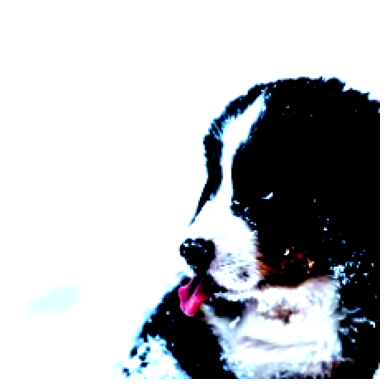

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# Prepare image for visualization
img = processed_image.squeeze(0)
img = img.permute(*torch.arange(img.ndim - 1, -1, -1))
img = np.einsum("ijk->jik", img)
# Visualize preprocessed image
plt.imshow(img)
plt.axis("off")

In [20]:
from transformers import CLIPModel
# Ensure 'model' refers to the CLIPModel from transformers
# model_id is defined in cell HW5VU0DDaHrQ
model = CLIPModel.from_pretrained(model_id)

image_embedding = model.get_image_features(processed_image)
image_embedding.shape()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

AttributeError: 'BaseModelOutputWithPooling' object has no attribute 'shape'

In [14]:
# Create text embedding (re-added as previous cell was deleted or incorrect)
text_output = model.get_text_features(**inputs)
text_embedding = text_output.pooler_output

# Create image embedding (missing from notebook state)
image_output = model.get_image_features(pixel_values=processed_image)
image_embedding = image_output.pooler_output

# Normalize the embeddings
text_embedding /= text_embedding.norm(dim=-1, keepdim=True)
image_embedding /= image_embedding.norm(dim=-1, keepdim=True)
# Calculate their similarity
text_embedding = text_embedding.detach().cpu().numpy()
image_embedding = image_embedding.detach().cpu().numpy()
score = np.dot(text_embedding, image_embedding.T)
score

array([[0.3362841]], dtype=float32)

In [19]:
from sentence_transformers import SentenceTransformer, util
# Load SBERT-compatible CLIP model
model = SentenceTransformer("clip-ViT-B-32")
# Encode the images
image_embeddings = model.encode(images)
# Encode the captions
text_embeddings = model.encode(captions)
#Compute cosine similarities
sim_matrix = util.cos_sim(
 image_embeddings, text_embeddings
)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

NameError: name 'images' is not defined

In [22]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration
import torch
# Load processor and main model
blip_processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
 "Salesforce/blip2-opt-2.7b",
 torch_dtype=torch.float16
)
# Send the model to GPU to speed up inference
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Blip2ForConditionalGeneration(
  (vision_model): Blip2VisionModel(
    (embeddings): Blip2VisionEmbeddings(
      (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): Blip2Encoder(
      (layers): ModuleList(
        (0-38): 39 x Blip2EncoderLayer(
          (self_attn): Blip2Attention(
            (qkv): Linear(in_features=1408, out_features=4224, bias=True)
            (projection): Linear(in_features=1408, out_features=1408, bias=True)
          )
          (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
          (mlp): Blip2MLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1408, out_features=6144, bias=True)
            (fc2): Linear(in_features=6144, out_features=1408, bias=True)
          )
          (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
  )
  (qf

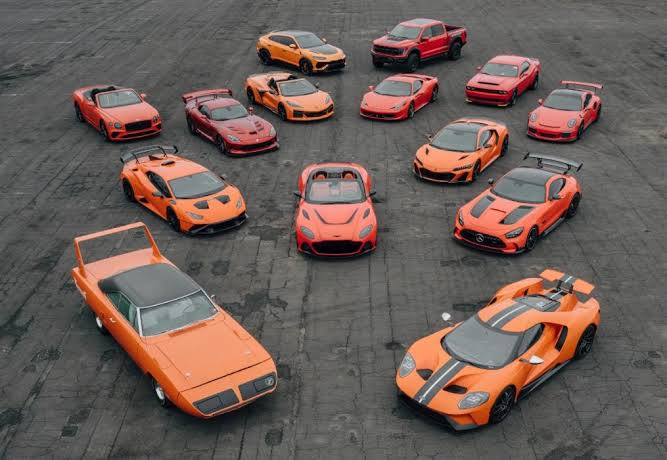

In [25]:
# Load image of a supercar
car_path = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQNa0OKXndBB_Lz9sbKSSsO1-zcQNw6NhRmQoD39HYh00Q8p3QF-leKRyVX&s=10"
image = Image.open(urlopen(car_path)).convert("RGB")
image

In [26]:
# Preprocess the image
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
inputs["pixel_values"].shape

torch.Size([1, 3, 224, 224])

In [27]:
blip_processor.tokenizer

TokenizersBackend(name_or_path='Salesforce/blip2-opt-2.7b', vocab_size=50265, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '<pad>'}, added_tokens_decoder={
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50265: AddedToken("<image>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

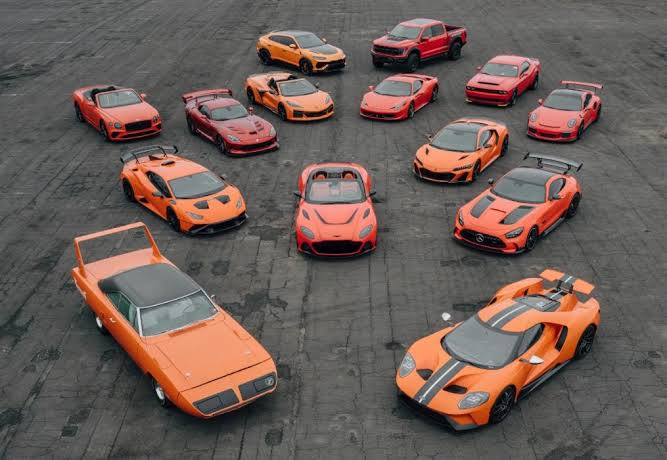

In [28]:
# Load an AI-generated image of a supercar
image = Image.open(urlopen(car_path)).convert("RGB")
# Convert an image into inputs and preprocess it
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
image

In [29]:
# Generate image ids to be passed to the decoder (LLM)
generated_ids = model.generate(**inputs, max_new_tokens=20)
# Generate text from the image ids
generated_text = blip_processor.batch_decode(
 generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text

'the cars are arranged in an orange circle'

In [31]:
# Load Rorschach image
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQT1EYmSvVFpu9LN-3jzc6HF5N7mJq2V0KpMAgntOSuUQ&s=10"
image = Image.open(urlopen(url)).convert("RGB")
# Generate caption
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=20)
generated_text = blip_processor.batch_decode(
 generated_ids, skip_special_tokens=True
)

In [32]:
generated_text = generated_text[0].strip()
generated_text

'a black and white image of a bat with a white background'

In [33]:
# Load an AI-generated image of a supercar
image = Image.open(urlopen(car_path)).convert("RGB")

In [34]:
# Visual question answering
prompt = "Question: Write down what you see in this picture. Answer:"
# Process both the image and the prompt
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device,
torch.float16)
# Generate text
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(
 generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text

'Question: Write down what you see in this picture. Answer: a bunch of orange sports cars'

In [35]:
# Chat-like prompting
prompt = "Question: Write down what you see in this picture. Answer: A sports car driving on the road at sunset. Question: What would it cost me to drive that car? Answer:"
# Generate output
inputs = blip_processor(image, text=prompt, return_tensors="pt").to(device,
torch.float16)
generated_ids = model.generate(**inputs, max_new_tokens=30)
generated_text = blip_processor.batch_decode(
 generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text


'Question: Write down what you see in this picture. Answer: A sports car driving on the road at sunset. Question: What would it cost me to drive that car? Answer: $1,000,000'

In [37]:
from IPython.display import HTML, display
import ipywidgets as widgets
def text_eventhandler(*args):
  question = args[0]["new"]
  if question:
    args[0]["owner"].value = ""
    # Create prompt
    if not memory:
      prompt = " Question: " + question + " Answer:"
    else:
      template = "Question: {} Answer: {}."
      prompt = " ".join(
      [
        template.format(memory[i][0], memory[i][1])
        for i in range(len(memory))
      ]
      ) + " Question: " + question + " Answer:"
    # Generate text
    inputs = blip_processor(image, text=prompt, return_tensors="pt")
    inputs = inputs.to(device, torch.float16)
    generated_ids = model.generate(**inputs, max_new_tokens=100)
    generated_text = blip_processor.batch_decode(
      generated_ids,
      skip_special_tokens=True
    )
    generated_text = generated_text[0].strip().split("Question")[0]
    # Update memory
    memory.append((question, generated_text))
    # Assign to output
    output.append_display_data(HTML("<b>USER:</b> " + question))
    output.append_display_data(HTML("<b>BLIP-2:</b> " + generated_text))
    output.append_display_data(HTML("<br>"))

# Prepare widgets
in_text = widgets.Text()
in_text.continuous_update = False
in_text.observe(text_eventhandler, "value")
output = widgets.Output()
memory = []

# Display chat box
display(
 widgets.VBox(
 children=[output, in_text],
 layout=widgets.Layout(display="inline-flex", flex_flow="columnreverse"),
 )
)

UnboundLocalError: cannot access local variable 'prompt' where it is not associated with a value